In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
OCORRENCIAS = r'C:\Users\eduarda.castilho\Documents\UC2_aulas\BASES\03.BaseDPEvolucaoMensalCisp.csv'
DP = r'C:\Users\eduarda.castilho\Documents\UC2_aulas\BASES\08.DP.csv'

df_ocorrencias = pd.read_csv(
    OCORRENCIAS,
    sep=';',
    encoding= 'iso-8859-1'
)

df_DP = pd.read_csv(
    DP

)

df_DP.head(10)

,codDP,nome,endereco
0,1,001ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
1,4,004ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
2,5,005ª DP - Mem de Sá,"Avenida Gomes Freire, 320 - Centro, Rio de Jan..."
3,6,006ª DP - Cidade Nova,"Rua Professor Clementino Fraga, 77 - Centro, R..."
4,7,007ª DP - Santa Teresa,"Rua Francisco de Castro, 5 - Santa Teresa, Rio..."
5,9,009ª DP - Catete,"Rua Pedro Américo, 1 - Catete, Rio de Janeiro ..."
6,10,010ª DP - Botafogo,"Rua Bambina, 140 - Botafogo, Rio de Janeiro - ..."
7,11,011ª DP - Rocinha,"Rua Bertha Lutz, 80 - Gávea, Rio de Janeiro - ..."
8,12,012ª DP - Copacabana,"Rua Hilário de Gouveia, 102 - Copacabana, Rio ..."
9,13,013ª DP - Ipanema,"Avenida Nossa Senhora de Copacabana, 1260 - Co..."


In [14]:
df_merge = df_ocorrencias.merge(
    df_DP,
    how='left',
    right_on='codDP',
    left_on= 'cisp'
)

df_merge.columns


Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'letalidade_violenta', 'tentat_hom',
       'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa',
       'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua',
       'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia',
       'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque',
       'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos',
       'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca',
       'pessoas_desaparecidas'

In [15]:
df_roubo_veiculo = df_merge[[
    'cisp', 'nome', 'roubo_veiculo', 'ano', 'mes', 'regiao'
]]


In [ ]:
df_roubo_veiculo.info()
df_roubo_veiculo['nome'].isna() #verifica erros 
df_roubo_veiculo['nome'].isnull() #verifica vazio

# df_roubo_veiculo.dropna() # retira erros 
df_roubo_veiculo = \
df_roubo_veiculo.fillna('DP não informada.') #'completa' os erros 


<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   cisp           34848 non-null  int64
 1   nome           34787 non-null  str  
 2   roubo_veiculo  34848 non-null  int64
 3   ano            34848 non-null  int64
 4   mes            34848 non-null  int64
 5   regiao         34848 non-null  str  
dtypes: int64(4), str(2)
memory usage: 1.6 MB


In [18]:
df_roubo_agg = (
    df_roubo_veiculo.groupby('nome')['roubo_veiculo']
    .sum().reset_index().sort_values(by='roubo_veiculo', ascending=False)
)
df_roubo_agg

,nome,roubo_veiculo
51,059ª DP - Duque de Caxias,34657
56,064ª DP - São João de Meriti,30151
35,039ª DP - Pavuna,27005
30,034ª DP - Bangu,26367
23,027ª DP - Vicente de Carvalho,25649
...,...,...
76,092ª DP - Rio das Flores,8
114,139ª DP - Porciúncula,7
112,137ª DP - Miracema,6
115,140ª DP - Natividade,6


In [19]:
roubo_veiculo_array = np.array(df_roubo_agg['roubo_veiculo'])

media = np.mean(roubo_veiculo_array)
mediana = np.median(roubo_veiculo_array)
desvio = np.std(roubo_veiculo_array)

q1 = np.percentile(roubo_veiculo_array, 25)
q3 = np.percentile(roubo_veiculo_array, 75)
iqr = q3 - q1
#outliers - preparação
limite_inferior = q1 - 1.5*iqr
limite_superior = q3 + 1.5*iqr

In [20]:

print(f'Média: {media:.2f}')
print(f'Mediana: {mediana:.2f}')
print(f'Desvio padrão: {desvio:.2f}')
print(f'Q1: {q1:.2f}')
print(f'Q2/Mediana: {mediana:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Limite Inferior: {limite_inferior}')
print(f'Limite Superior: {limite_superior}')

Média: 4892.81
Mediana: 1197.00
Desvio padrão: 7188.34
Q1: 104.00
Q2/Mediana: 1197.00
Q3: 7275.00
IQR: 7171.00
Limite Inferior: -10652.5
Limite Superior: 18031.5


In [22]:
df_roubo_veiculo_outliers_inf = (
    df_roubo_agg[df_roubo_agg['roubo_veiculo'] < limite_inferior]
)
df_roubo_veiculo_outliers_sup = (
    df_roubo_agg[df_roubo_agg['roubo_veiculo'] > limite_superior]
)


In [23]:
if len(df_roubo_veiculo_outliers_inf) <= 0:
    print('Não há outliers inferiores')
else:
        print(f'Há {len(df_roubo_veiculo_outliers_inf)} outliers inferiores. ')

if len(df_roubo_veiculo_outliers_sup) <= 0:
    print('Não há outliers superiores')
else:
        print(f'Há {len(df_roubo_veiculo_outliers_sup)} outliers superiores. ')

Não há outliers inferiores
Há 10 outliers superiores. 


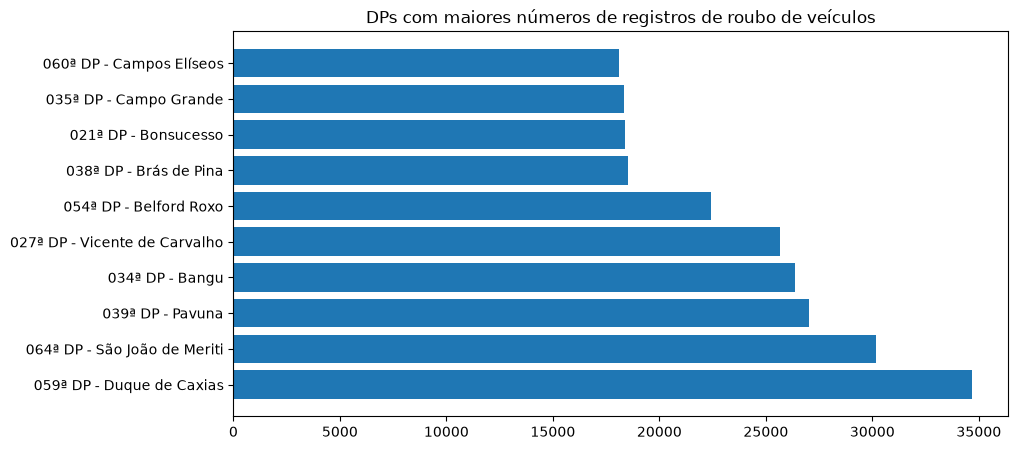

C:\Users\eduarda.castilho\AppData\Local\Temp\ipykernel_26900\383471046.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_roubo_agg['roubo_veiculo'], showmeans=True, vert=False)


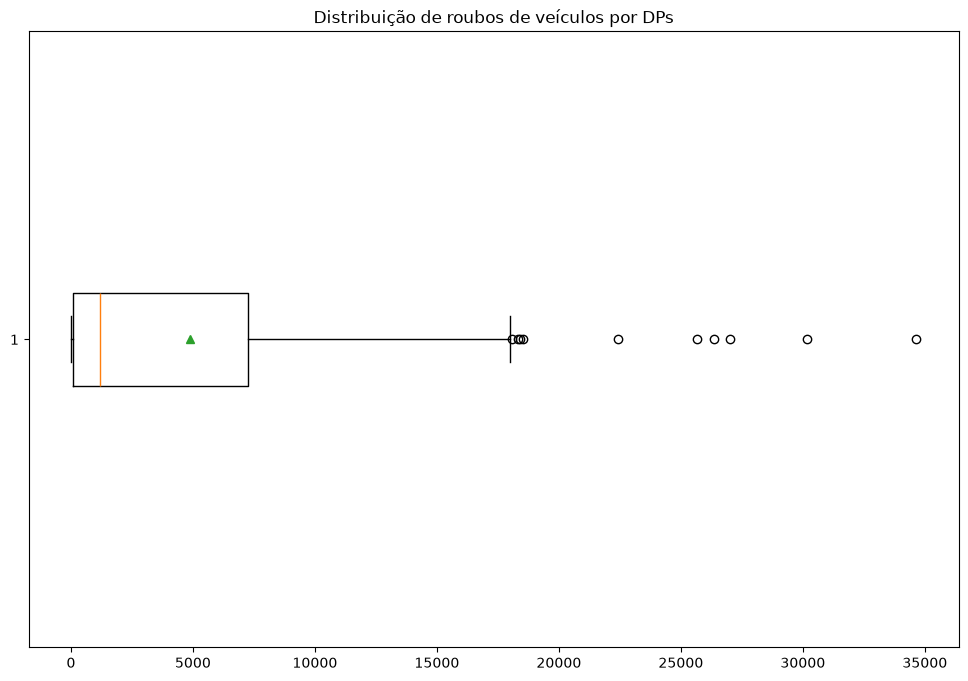

In [41]:
plt.figure(figsize=(10, 5))
plt.barh(df_roubo_veiculo_outliers_sup['nome'],
        df_roubo_veiculo_outliers_sup['roubo_veiculo'])
plt.title('DPs com maiores números de registros de roubo de veículos')
plt.show()

plt.figure(figsize=(12, 8))
plt.boxplot(df_roubo_agg['roubo_veiculo'], showmeans=True, vert=False)
plt.title('Distribuição de roubos de veículos por DPs')
plt.show()

In [43]:
df_rec_veiculo = df_merge[[
    'cisp', 'nome', 'recuperacao_veiculos'
]]

df_rec_agg = (
    df_rec_veiculo.groupby('nome')['recuperacao_veiculos']
    .sum().reset_index()
    .sort_values(by='recuperacao_veiculos', ascending=False)
)
correlacao = (
    df_roubo_agg['roubo_veiculo'].corr(df_rec_agg['recuperacao_veiculos'])
)

print(f'Correlação: {correlacao:.4f}')

Correlação: 0.9309
